In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving True.csv to True.csv
Saving Fake.csv to Fake.csv


In [ ]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

print("Fake News Dataset Shape:", fake.shape)
print("True News Dataset Shape:", true.shape)

Fake News Dataset Shape: (23481, 4)
True News Dataset Shape: (21417, 4)


In [ ]:
fake["label"] = 0
true["label"] = 1

In [ ]:
df = pd.concat([fake, true], axis=0)

print("Combined Dataset Shape:", df.shape)

df.head()

Combined Dataset Shape: (44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [ ]:
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

Missing Values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [ ]:
df = df[["title", "text", "label"]]

df = df.dropna()

df.head()

,title,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0


In [ ]:
df["content"] = df["title"] + " " + df["text"]

df = df[["content", "label"]]

df.head()

,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,0
1,Drunk Bragging Trump Staffer Started Russian ...,0
2,Sheriff David Clarke Becomes An Internet Joke...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,0
4,Pope Francis Just Called Out Donald Trump Dur...,0


In [ ]:
print(df["label"].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


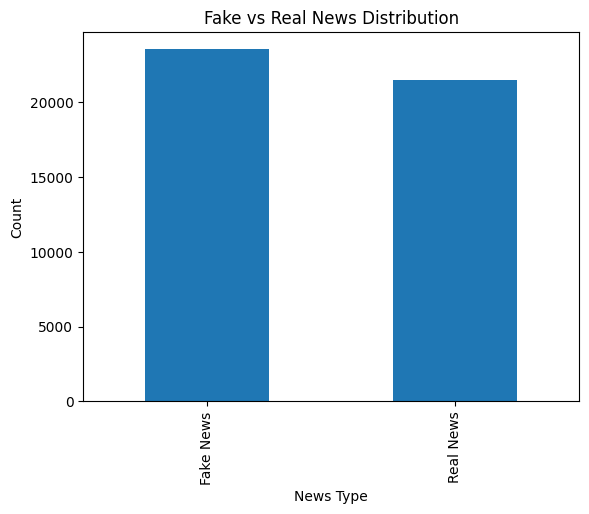

In [ ]:
df["label"].value_counts().plot(
    kind="bar"
)

plt.xticks([0, 1], ["Fake News", "Real News"])
plt.xlabel("News Type")
plt.ylabel("Count")
plt.title("Fake vs Real News Distribution")

plt.show()

In [ ]:
X = df["content"]
y = df["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (35918,)
Testing Data: (8980,)


In [ ]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.7,
    max_features=50000
)

X_train_vectorized = vectorizer.fit_transform(X_train)

X_test_vectorized = vectorizer.transform(X_test)

print("Vectorization Completed!")

Vectorization Completed!


In [ ]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_vectorized,
    y_train
)

print("Model Training Completed!")

Model Training Completed!


In [ ]:
y_pred = model.predict(X_test_vectorized)

print(y_pred[:10])

[0 1 1 0 1 0 0 0 1 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy * 100, "%")

Model Accuracy: 98.60801781737194 %


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fake News", "Real News"]
))

              precision    recall  f1-score   support

   Fake News       0.99      0.99      0.99      4733
   Real News       0.98      0.99      0.99      4247

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4663   70]
 [  55 4192]]


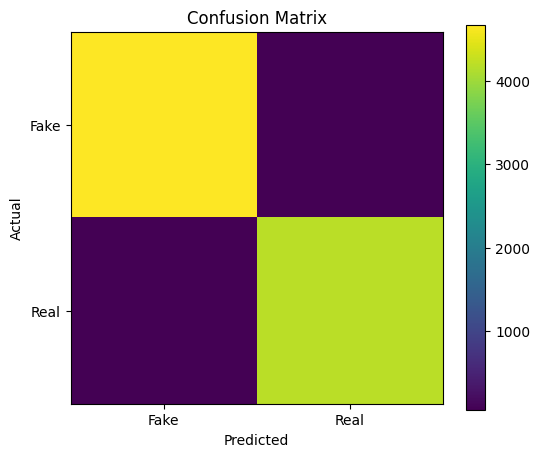

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.colorbar()

plt.xticks([0, 1], ["Fake", "Real"])
plt.yticks([0, 1], ["Fake", "Real"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
def predict_news(news):

    news_vector = vectorizer.transform([news])

    prediction = model.predict(news_vector)

    if prediction[0] == 0:
        return "❌ FAKE NEWS"
    else:
        return "✅ REAL NEWS"

In [ ]:
news = """Scientists confirm that a new technology can improve renewable energy production."""

result = predict_news(news)

print("Prediction:", result)

Prediction: ✅ REAL NEWS
